<a href="https://colab.research.google.com/github/Allahbachayo786/abm.demo/blob/main/fifa_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/fifa_world_cup_2026_player_performance.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()
df.info()

Shape: (54600, 75)

Columns: ['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rati

In [ ]:
# Drop completely empty rows
df = df.dropna(how='all')

# Remove duplicates
df = df.drop_duplicates()

# Check if columns are shifted - example: if jersey_num is in team column
# You might need to manually fix based on your file
# df = df[['player_id','player_name','age','nationality','team','jersey_num',...]]

In [ ]:
# See missing values
print(df.isnull().sum())

# Fill numeric with median
num_cols = ['age', 'height_cm', 'weight_kg', 'market_value_eur']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill text with "Unknown"
text_cols = ['club_name', 'preferred_foot']
for col in text_cols:
    df[col] = df[col].fillna('Unknown')

player_id                   0
player_name                 0
age                         0
nationality                 0
team                        0
                           ..
total_goals_tournament      0
total_assists_tournament    0
total_minutes_tournament    0
player_of_match_awards      0
tournament_rating           0
Length: 75, dtype: int64


In [ ]:
# Convert to correct types
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['height_cm'] = pd.to_numeric(df['height_cm'], errors='coerce')
df['weight_kg'] = pd.to_numeric(df['weight_kg'], errors='coerce')
df['jersey_number'] = pd.to_numeric(df['jersey_number'], errors='coerce')

# 'market_value_eur' is already numeric (int64) and does not require cleaning

# Convert date
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')

In [ ]:
# Standardize text columns
df['position'] = df['position'].str.title()
df['preferred_foot'] = df['preferred_foot'].str.title()
df['nationality'] = df['nationality'].str.title()
df['team'] = df['team'].str.title()

# Fix position abbreviations if any
position_map = {'Mid': 'Midfielder', 'Def': 'Defender', 'Fwd': 'Forward', 'GK': 'Goalkeeper'}
df['position'] = df['position'].replace(position_map)

In [ ]:
# BMI
df['bmi'] = df['weight_kg'] / ((df['height_cm']/100) ** 2)

# Age groups
bins = [0, 21, 28, 50]
labels = ['U21', '21-28', '29+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

# Market value in millions
df['market_val_m'] = df['market_value_eur'] / 1000000

# Extract from date
df['match_year'] = df['match_date'].dt.year
df['match_month'] = df['match_date'].dt.month

In [ ]:
# Only Spain match on 10/07/2026
df_spain = df[(df['match_id'] == 'M00001') & (df['match_date'] == '2026-10-07')]

# Or keep everything
# df_filtered = df.copy()

In [ ]:
# Final checks
print("Missing values after cleaning:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.describe())

# Save cleaned file
df.to_csv('fifa_world_cup_2026_cleaned.csv', index=False)

Missing values after cleaning:
 player_id       0
player_name     0
age             0
nationality     0
team            0
               ..
bmi             0
age_group       0
market_val_m    0
match_year      0
match_month     0
Length: 80, dtype: int64
Duplicates: 0
                age  jersey_number     height_cm     weight_kg  \
count  54600.000000   54600.000000  54600.000000  54600.000000   
mean      26.296484      13.500000    181.654341     75.754853   
min       17.000000       1.000000    163.000000     65.000000   
25%       23.000000       7.000000    177.000000     73.000000   
50%       26.000000      13.500000    182.000000     76.000000   
75%       29.000000      20.000000    186.000000     78.000000   
max       39.000000      26.000000    200.000000     87.000000   
std        4.067519       7.500069      6.277792      3.951481   

       market_value_eur                     match_date    goals_team  \
count      5.460000e+04                          54600  54600.00

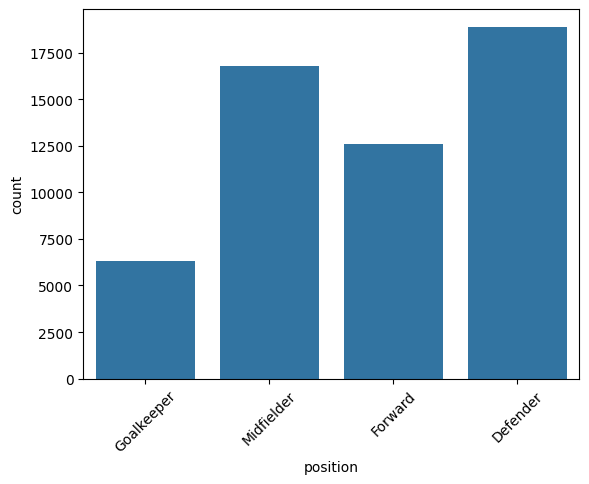

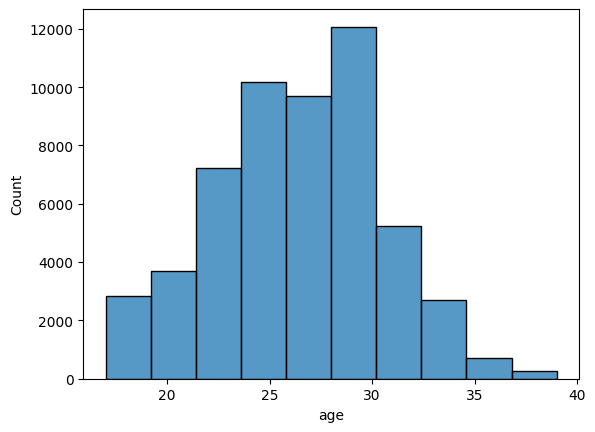

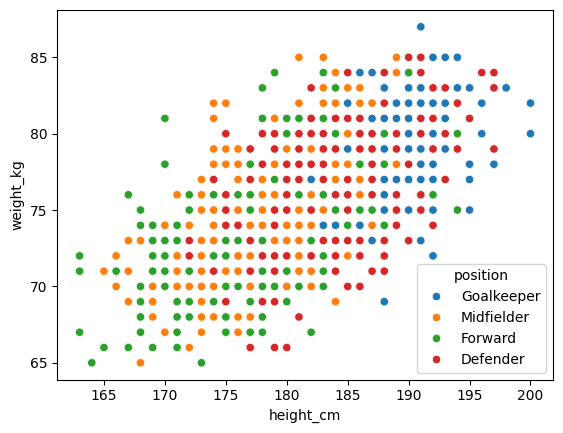

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Players per position
sns.countplot(data=df, x='position')
plt.xticks(rotation=45)
plt.show()

# 2. Avg market value by position
df.groupby('position')['market_val_m'].mean().sort_values(ascending=False)

# 3. Top 5 most valuable
df[['player_name', 'club_name', 'market_val_m']].sort_values('market_val_m', ascending=False).head()

# 4. Age distribution
sns.histplot(df['age'], bins=10)
plt.show()

# 5. Height vs Weight
sns.scatterplot(data=df, x='height_cm', y='weight_kg', hue='position')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Choose features
features = ['age', 'height_cm', 'weight_kg', 'position', 'preferred_foot', 'nationality']
target = 'market_value_eur'

df_ml = df[features + [target]].dropna()

# Encode text columns
le = LabelEncoder()
for col in ['position', 'preferred_foot', 'nationality']:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml[features]
y = df_ml[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numbers
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 1.0
MAE: 0.0


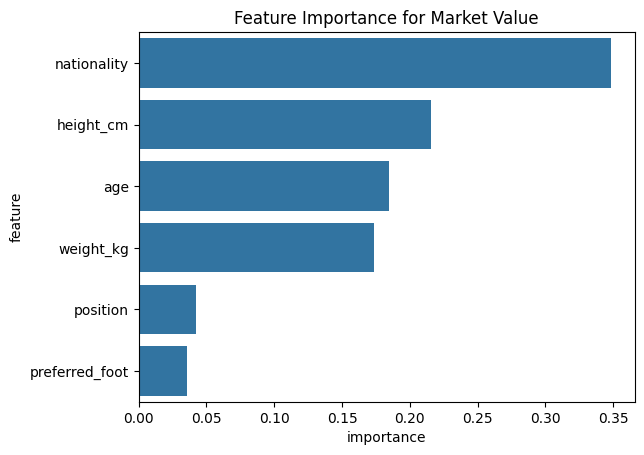

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(data=importance, x='importance', y='feature')
plt.title("Feature Importance for Market Value")
plt.show()

In [ ]:
new_player = [[24, 180, 75, 2, 1, 5]] # age, height, weight, encoded position, foot, nationality
predicted_value = model.predict(scaler.transform(new_player))
print("Predicted Market Value:", predicted_value[0])

Predicted Market Value: 15956622.74


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# Use same X_train, X_test from before
# But don't use StandardScaler twice. Reset it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1) # output = market_val
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

history = model.fit(X_train_scaled, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1135296087326720.0000 - mae: 19995188.0000 - val_loss: 1145973778677760.0000 - val_mae: 19750744.0000
Epoch 2/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1046163100794880.0000 - mae: 18060740.0000 - val_loss: 969346939617280.0000 - val_mae: 16346386.0000
Epoch 3/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 845166550188032.0000 - mae: 15680188.0000 - val_loss: 793601038614528.0000 - val_mae: 15875396.0000
Epoch 4/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 749966855241728.0000 - mae: 16377475.0000 - val_loss: 755385023594496.0000 - val_mae: 16813976.0000
Epoch 5/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 732818795659264.0000 - mae: 17012216.0000 - val_loss: 747325785899008.0000 - val_mae: 17146492.0000
Epoch 6/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 729361615421440.0000 - mae: 17199992.0000 - val_loss: 744418495692800.0000 - val_mae: 17326710.0000
Epoch 7/50
1092/1092 ━━━━

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 714978910797824.0000 - mae: 17458302.0000
Test MAE: 17458302.0


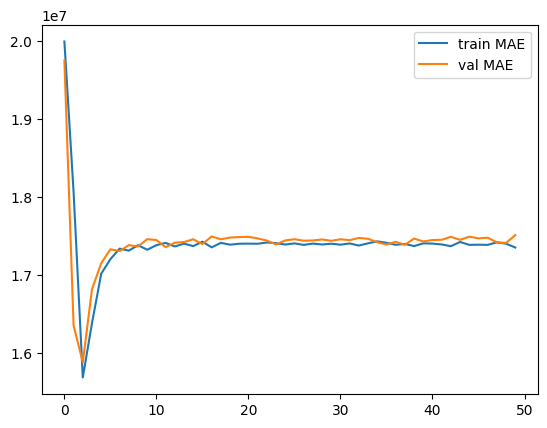

In [ ]:
loss, mae = model.evaluate(X_test_scaled, y_test)
print("Test MAE:", mae)

# Plot training
import matplotlib.pyplot as plt
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.legend()
plt.show()